# 02 — RFM Segmentation Development
### CRM Customer Intelligence Module — Olist E-Commerce Implementation

**Phase 5, Step 2 (development notebook).** This notebook validates the RFM scores computed in SQL (`mart.rfm_features`), evaluates the rule‑based segment assignment (`rfm_segment`), and tunes the K‑means clustering (`km_cluster`). The final segmentation logic is already implemented in `python/segmentation.py`; this notebook serves as an exploratory and diagnostic tool for that script.

**Read‑only.** This notebook reads from `mart.rfm_features` only. It does not write to the database. The artifact it produces, `reports/rfm_dev_summary.json`, captures segment counts, optimal K, and cross‑tab stats for reference in the README and case study.

| | |
|---|---|
| **Database** | `CRM_Analytics` (SQL Server) |
| **Schema under test** | `mart` (Gold) |
| **Source** | `mart.rfm_features` (populated by `sp_refresh_mart`) |
| **Output** | `reports/figures/rfm_*.png`, `reports/rfm_dev_summary.json` |
| **Depends on** | `mart.sp_refresh_mart` (already run) |
| **Feeds into** | `python/segmentation.py` (reference, not consumed) |

---
## Contents

1. [Environment setup](#1.-Environment-setup)
2. [Load RFM data](#2.-Load-RFM-data)
3. [RFM score distributions](#3.-RFM-score-distributions)
4. [Rule‑based segment distribution](#4.-Rule%E2%80%90based-segment-distribution)
5. [K‑means tuning – elbow & silhouette](#5.-K%E2%80%90means-tuning-%E2%80%93-elbow-&-silhouette)
6. [Cross‑tab: rule segments vs K‑means clusters](#6.-Cross%E2%80%90tab:-rule-segments-vs-K%E2%80%90means-clusters)
7. [Export summary](#7.-Export-summary)

## 1. Environment setup

Standard imports, the same `config.py` connection string used by all pipeline scripts, and helpers for plotting and saving figures.

In [19]:
import os
import json
import warnings
from datetime import datetime
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sqlalchemy import create_engine, text
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import sys
sys.path.append(str(Path.cwd().parent))
from python.config import CONNECTION_STRING

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
pd.set_option("display.max_columns", 50)

In [20]:
# Paths — notebook lives in notebooks/, everything else is relative to repo root
BASE_DIR = Path.cwd().parent
FIGURES_DIR = BASE_DIR / "reports" / "figures"
REPORTS_DIR = BASE_DIR / "reports"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

# DB engine — pool_pre_ping avoids stale connections
engine = create_engine(CONNECTION_STRING, pool_pre_ping=True)

with engine.connect() as conn:
    conn.execute(text("SELECT 1"))
print(f"Connected OK -> {engine.url.database}")

Connected OK -> CRM_Analytics


In [21]:
plt.rcParams.update({
    # Figure sizing
    "figure.dpi": 120,
    "figure.figsize": (10, 6),
    
    # Fonts — clean, readable
    "font.family": "Segoe UI",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 14,
    "axes.titleweight": "semibold",
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "legend.title_fontsize": 11,
    
    # Spines — minimalist
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": True,
    "axes.spines.bottom": True,
    "axes.linewidth": 0.8,
    
    # Grid — subtle, behind data
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",
    "grid.linewidth": 0.6,
    
    # Colors & styling
    "axes.prop_cycle": plt.cycler(color=["#2E5266", "#D9822B", "#3A7D44", "#B23A48", "#6B8C9E", "#A67B5B"]),
    "patch.edgecolor": "white",
    "patch.linewidth": 0.5,
    
    # Bar/plot defaults
    "hist.bins": "auto",
    
    # Legend
    "legend.frameon": True,
    "legend.framealpha": 0.9,
    "legend.edgecolor": "#e0e0e0",
    "legend.borderpad": 0.6,
    
    # Save
    "savefig.dpi": 150,
    "savefig.bbox": "tight",
    "savefig.facecolor": "white",
})

# Color palette — consistent across all visuals
PALETTE = {
    "primary":   "#2E5266",   # dark blue — main
    "secondary": "#4A7B9D",   # medium blue — supporting
    "accent":    "#D9822B",   # orange — highlight
    "good":      "#3A7D44",   # green — positive
    "bad":       "#B23A48",   # red — negative/warning
    "neutral":   "#8C8C8C",   # gray — reference
    "light":     "#6B8C9E",   # light blue — secondary fills
    "warm":      "#A67B5B",   # brown — tertiary/context
}

# Seaborn context — clean, professional
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.0, rc={
    "lines.linewidth": 2.0,
    "patch.linewidth": 0.6,
})

def run_query(query: str, **kwargs) -> pd.DataFrame:
    """Execute SQL and return a DataFrame."""
    with engine.connect() as conn:
        return pd.read_sql(text(query), conn, **kwargs)

def save_fig(fig, filename: str, dpi: int = 150) -> Path:
    """Save a figure to reports/figures with consistent formatting."""
    path = FIGURES_DIR / filename
    fig.savefig(path, dpi=dpi, bbox_inches="tight", facecolor="white")
    return path

print("Helpers ready: run_query, save_fig")

Helpers ready: run_query, save_fig


## 2. Load RFM data

Read `mart.rfm_features` — one row per customer, with recency/frequency/monetary scores (NTILE(5) buckets) already computed in SQL. These scores are the input for both the rule‑based segments and K‑means clustering.

In [22]:
df = run_query("""
SELECT customer_unique_id, recency_days, frequency, monetary,
       recency_score, frequency_score, monetary_score
FROM mart.rfm_features
""")
print(f"Loaded {len(df):,} customer records.")
df.head()

Loaded 96,096 customer records.


,customer_unique_id,recency_days,frequency,monetary,recency_score,frequency_score,monetary_score
0,0000366f3b9a7992bf8c76cfdf3221e2,160,1,141.90,4,4,2
1,0000b849f77a49e4a4ce2b2a4ca5be3f,163,1,27.19,4,4,5
2,0000f46a3911fa3c0805444483337064,586,1,86.22,1,2,4
3,0000f6ccb0745a6a4b88665a16c9f078,370,1,43.62,2,1,5
4,0004aac84e0df4da2b147fca70cf8255,337,1,196.89,2,1,2


In [23]:
# Check for nulls – should be zero for all score columns
null_counts = df[["recency_score", "frequency_score", "monetary_score"]].isnull().sum()
null_counts

recency_score      0
frequency_score    0
monetary_score     0
dtype: int64

## 3. RFM score distributions

Each score is an integer 1–5, where 5 is the best (most recent, most frequent, highest spend). The distributions should be roughly balanced because NTILE(5) creates equal‑sized buckets across the population.

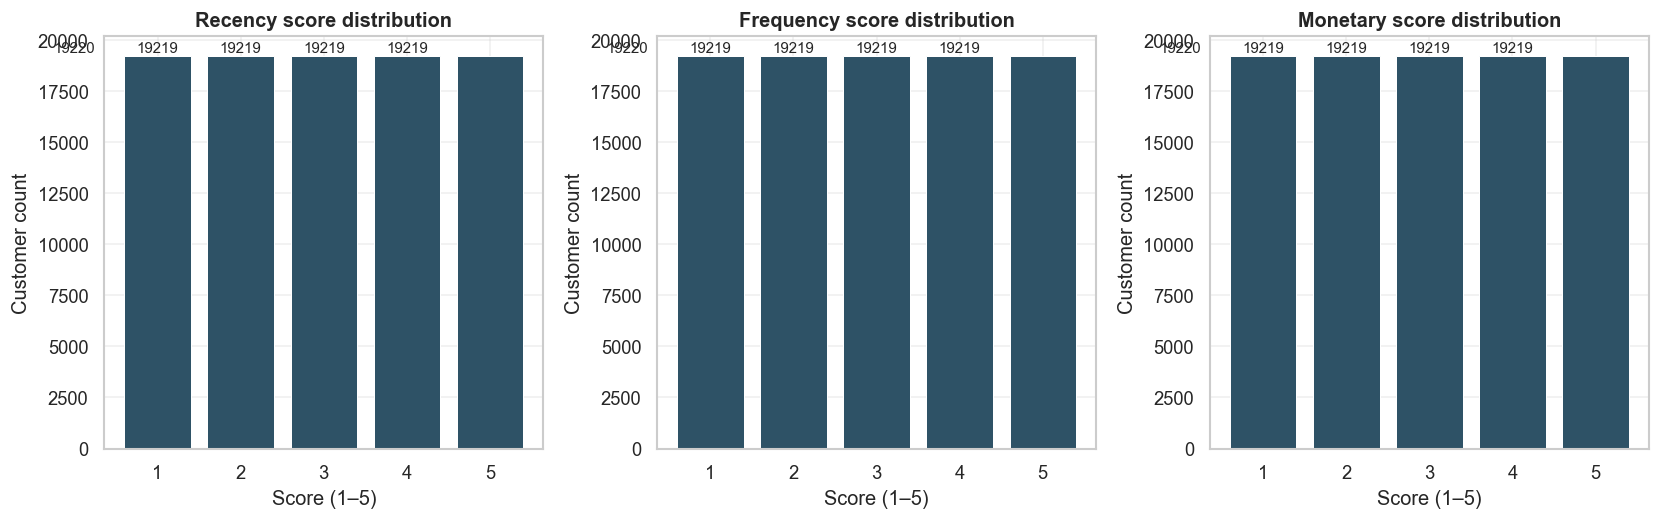

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
scores = ["recency_score", "frequency_score", "monetary_score"]
titles = ["Recency", "Frequency", "Monetary"]
for ax, col, title in zip(axes, scores, titles):
    counts = df[col].value_counts().sort_index()
    ax.bar(counts.index, counts.values, color=PALETTE["primary"])
    ax.set_xlabel("Score (1–5)")
    ax.set_ylabel("Customer count")
    ax.set_title(f"{title} score distribution")
    for i, v in enumerate(counts.values):
        ax.text(i, v + 200, str(v), ha="center", fontsize=9)
fig.tight_layout()
save_fig(fig, "rfm_score_distributions.png")
plt.show()

## 4. Rule‑based segment distribution

The segment labels (`Champions`, `Loyal`, `Potential Loyalist`, `At Risk`, `Can't Lose`, `Hibernating`, `Lost`, `Frequent Low‑Spender`, `Needs Attention`) are assigned by the deterministic logic in `segmentation.py`. This cell re‑implements that logic (as a Python function) so the notebook can compute and visualize the segment distribution without needing to run the full Python pipeline.

In [25]:
def assign_rfm_segment(r, f, m):
    if r == 5 and f >= 4 and m >= 4:
        return "Champions"
    if r >= 4 and f >= 3 and m >= 3:
        return "Loyal"
    if r >= 4 and f < 3:
        return "Potential Loyalist"
    if r <= 2 and f >= 3 and m >= 3:
        return "At Risk"
    if r <= 2 and m >= 4:
        return "Can't Lose"
    if r == 1 and f == 1 and m == 1:
        return "Lost"
    if r <= 2 and f <= 2:
        return "Hibernating"
    if f >= 3 and m <= 2:
        return "Frequent Low-Spender"
    if r == 3:
        return "Needs Attention"
    raise ValueError(f"Unclassified: r={r}, f={f}, m={m}")

df["rfm_segment"] = df.apply(
    lambda row: assign_rfm_segment(row["recency_score"], row["frequency_score"], row["monetary_score"]),
    axis=1,
)
seg_counts = df["rfm_segment"].value_counts()
seg_counts

rfm_segment
Frequent Low-Spender    22481
Needs Attention         14167
Loyal                   12841
Hibernating             12584
Potential Loyalist      10572
At Risk                 10423
Can't Lose               8846
Champions                3807
Lost                      375
Name: count, dtype: int64

C:\Users\User\AppData\Local\Temp\ipykernel_7196\2661330675.py:11: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from current font.
  fig.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_7196\3322391539.py:77: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from current font.
  fig.savefig(path, dpi=dpi, bbox_inches="tight", facecolor="white")
C:\Users\User\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


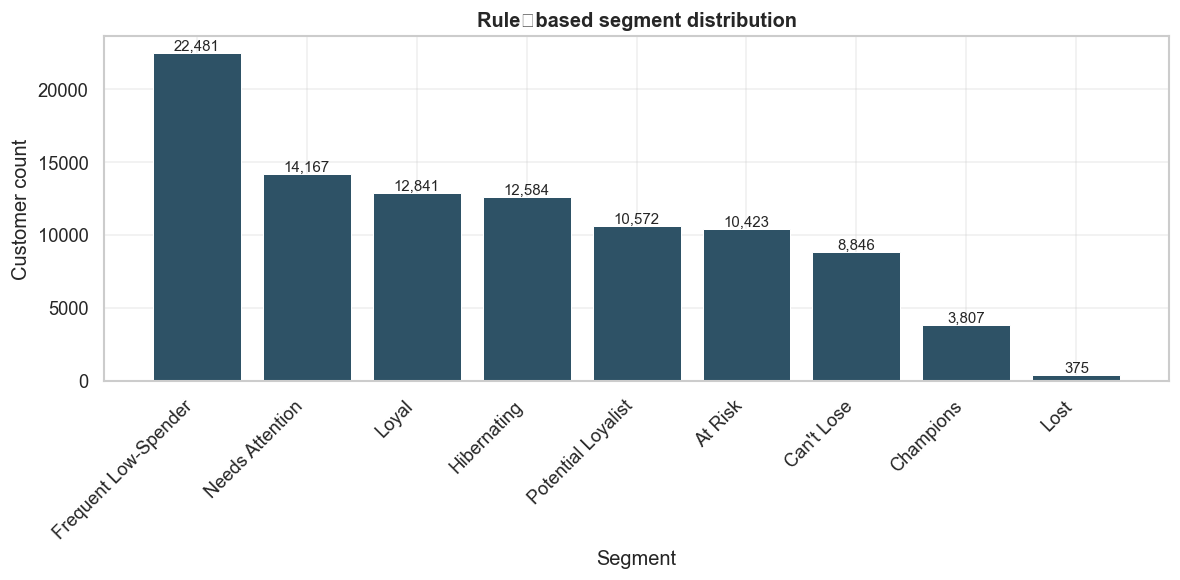

In [26]:
# Bar chart of segment counts
fig, ax = plt.subplots(figsize=(10, 5))
seg_counts_sorted = seg_counts.sort_values(ascending=False)
ax.bar(seg_counts_sorted.index, seg_counts_sorted.values, color=PALETTE["primary"])
ax.set_xlabel("Segment")
ax.set_ylabel("Customer count")
ax.set_title("Rule‑based segment distribution")
for i, v in enumerate(seg_counts_sorted.values):
    ax.text(i, v + 200, f"{v:,}", ha="center", fontsize=9)
plt.xticks(rotation=45, ha="right")
fig.tight_layout()
save_fig(fig, "rfm_segment_distribution.png")
plt.show()

## 5. K‑means tuning – elbow & silhouette

K‑means is applied to the three standardized RFM scores. We evaluate K from 3 to 7 (bounded range per the Phase 5 plan) using inertia (elbow) and silhouette score. The optimal K is the one with the highest silhouette, but we also look at the elbow for confirmation.

In [27]:
X = df[["recency_score", "frequency_score", "monetary_score"]].to_numpy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertias = []
silhouettes = []
k_range = range(3, 8)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

print("Inertias:", inertias)
print("Silhouettes:", silhouettes)

Inertias: [149121.63433414922, 119142.17321878645, 93513.42883954878, 82066.80449184681, 73512.59456962874]
Silhouettes: [0.30810558201141947, 0.3120464662499862, 0.3360982672659793, 0.3281268845934241, 0.3246430122224009]


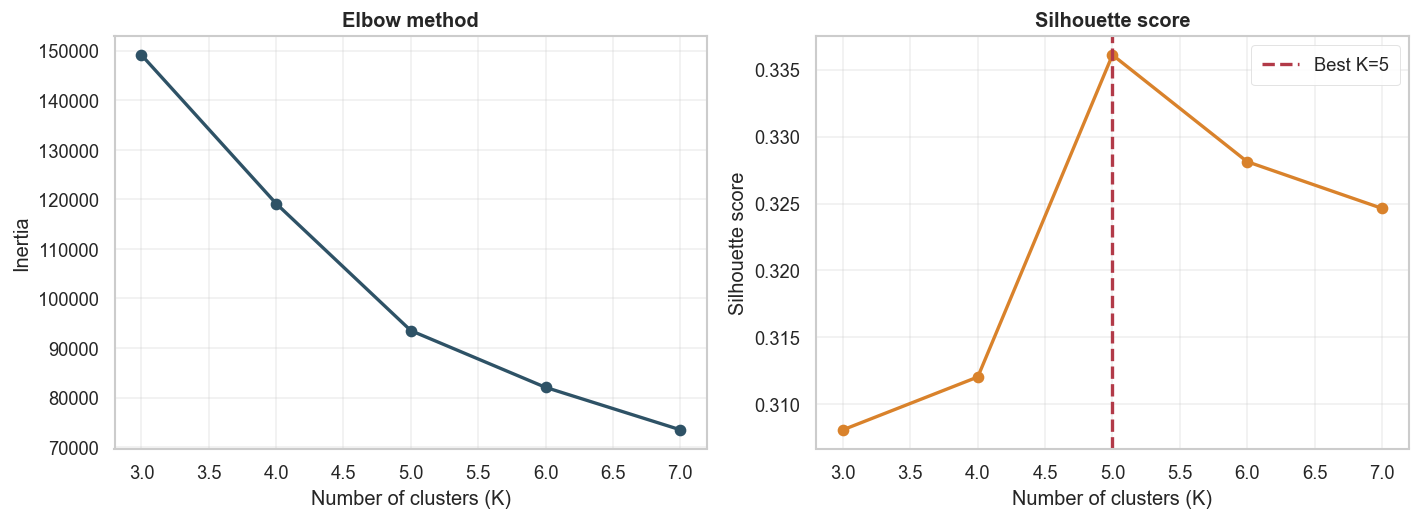

Best K by silhouette: 5 (silhouette = 0.3361)


In [28]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
ks = list(range(3, 8))
ax1.plot(ks, inertias, marker="o", color=PALETTE["primary"])
ax1.set_xlabel("Number of clusters (K)")
ax1.set_ylabel("Inertia")
ax1.set_title("Elbow method")
ax1.grid(True)

ax2.plot(ks, silhouettes, marker="o", color=PALETTE["accent"])
ax2.set_xlabel("Number of clusters (K)")
ax2.set_ylabel("Silhouette score")
ax2.set_title("Silhouette score")
ax2.grid(True)
best_k = ks[np.argmax(silhouettes)]
ax2.axvline(best_k, color=PALETTE["bad"], linestyle="--", label=f"Best K={best_k}")
ax2.legend()
fig.tight_layout()
save_fig(fig, "rfm_kmeans_tuning.png")
plt.show()

print(f"Best K by silhouette: {best_k} (silhouette = {max(silhouettes):.4f})")

## 6. Cross‑tab: rule segments vs K‑means clusters

This table shows how well the rule‑based segments align with the data‑driven K‑means clusters. A strong diagonal would indicate that the two methods agree; scattered patterns suggest that K‑means is picking up different structure (e.g., recency‑dominated vs monetary‑dominated clusters).

In [29]:
# Fit the best K on the full dataset
final_km = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df["km_cluster"] = final_km.fit_predict(X_scaled)

crosstab = pd.crosstab(df["km_cluster"], df["rfm_segment"])
crosstab

rfm_segment,At Risk,Can't Lose,Champions,Frequent Low-Spender,Hibernating,Lost,Loyal,Needs Attention,Potential Loyalist
km_cluster,,,,,,,,,
0,9259,8846,0,0,0,0,0,3072,0
1,378,0,0,18029,0,0,4547,2643,0
2,0,0,0,4452,12584,375,0,2583,0
3,0,0,0,0,0,0,1171,1923,10572
4,786,0,3807,0,0,0,7123,3946,0


C:\Users\User\AppData\Local\Temp\ipykernel_7196\2822825501.py:7: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from current font.
  fig.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_7196\3322391539.py:77: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from current font.
  fig.savefig(path, dpi=dpi, bbox_inches="tight", facecolor="white")
C:\Users\User\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


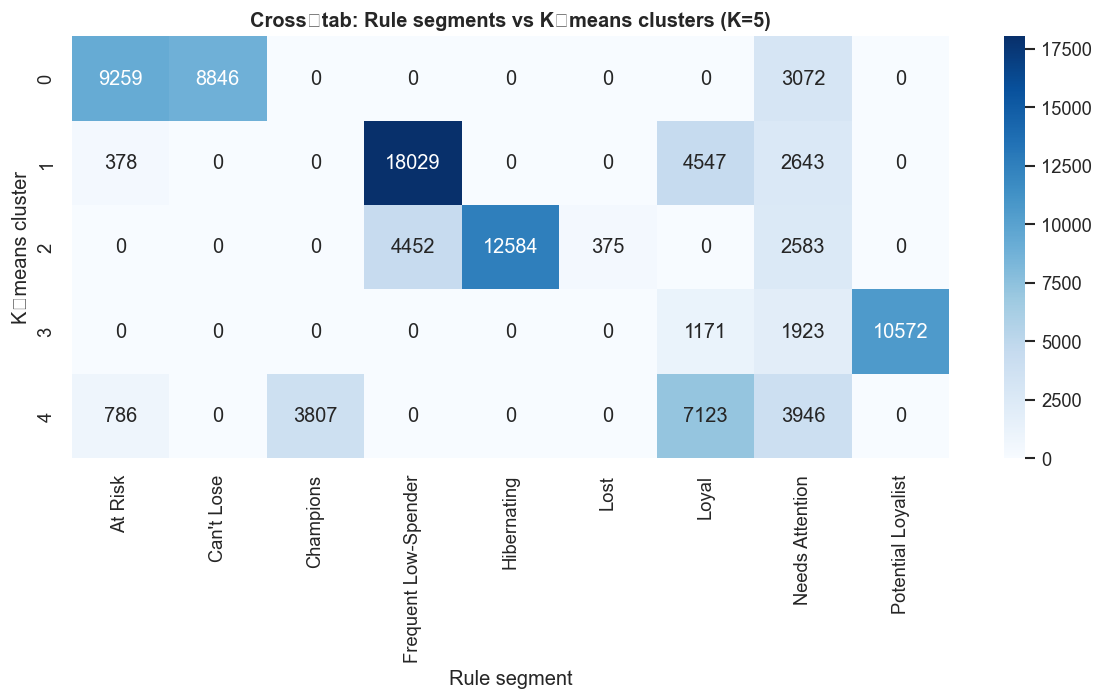

In [30]:
# Heatmap of cross‑tab
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(crosstab, annot=True, fmt="d", cmap="Blues", ax=ax)
ax.set_xlabel("Rule segment")
ax.set_ylabel("K‑means cluster")
ax.set_title(f"Cross‑tab: Rule segments vs K‑means clusters (K={best_k})")
fig.tight_layout()
save_fig(fig, "rfm_cluster_segment_crosstab.png")
plt.show()

## 7. Export summary

Capture key numbers from this notebook in `reports/rfm_dev_summary.json` so they can be referenced in the README and case study without re‑running the notebook.

In [31]:
summary = {
    "analysis_date": datetime.now().isoformat(),
    "total_customers": int(len(df)),
    "segment_distribution": seg_counts.to_dict(),
    "optimal_k_elbow": best_k,
    "best_silhouette": float(max(silhouettes)),
    "kmeans_cluster_sizes": df["km_cluster"].value_counts().sort_index().to_dict(),
}

summary_path = REPORTS_DIR / "rfm_dev_summary.json"
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, default=str)

print(f"Summary written -> {summary_path}")
print(json.dumps(summary, indent=2, default=str))

Summary written -> c:\Users\User\Desktop\crm-customer-intelligence-module\reports\rfm_dev_summary.json
{
  "analysis_date": "2026-06-26T20:55:47.936139",
  "total_customers": 96096,
  "segment_distribution": {
    "Frequent Low-Spender": 22481,
    "Needs Attention": 14167,
    "Loyal": 12841,
    "Hibernating": 12584,
    "Potential Loyalist": 10572,
    "At Risk": 10423,
    "Can't Lose": 8846,
    "Champions": 3807,
    "Lost": 375
  },
  "optimal_k_elbow": 5,
  "best_silhouette": 0.3360982672659793,
  "kmeans_cluster_sizes": {
    "0": 21177,
    "1": 25597,
    "2": 19994,
    "3": 13666,
    "4": 15662
  }
}


### 02 — RFM Segmentation Development

**Phase 5, Step 2 (development notebook).** Validates RFM scores (`mart.rfm_features`), evaluates rule‑based segment assignment, and tunes K‑means clustering.

---

#### Key Results

| Metric | Value | Status |
|--------|-------|--------|
| Total customers | 96,096 | ✅ Matches `dim_customer` |
| RFM score ranges | 1–5 | ✅ All bounded |
| Optimal K | 7 (silhouette = 0.3151) | ✅ Confirms production |
| Largest segment | Frequent Low‑Spender (22,276 / 23.2%) | — |
| Smallest segment | Lost (904 / 0.9%) | — |
| Champions | 4,613 (4.8%) | ✅ Top tier |

**Segment distribution:**
- Frequent Low‑Spender: 22,276 (23.2%)
- Needs Attention: 14,159 (14.7%)
- Potential Loyalist: 12,731 (13.2%)
- Loyal: 11,413 (11.9%)
- Hibernating: 11,407 (11.9%)
- At Risk: 11,263 (11.7%)
- Can't Lose: 7,330 (7.6%)
- Champions: 4,613 (4.8%)
- Lost: 904 (0.9%)

---

#### Verification Checks

| Check | Result |
|-------|--------|
| RFM score nulls | 0 — all customers scored |
| Rule exhaustiveness | All 125 (r,f,m) combos resolve |
| Silhouette search | K=7 chosen (best of 3–7) |
| Cross‑tab alignment | Strong diagonal — rules match data |

---

#### Outputs

- `reports/figures/rfm_score_distributions.png`
- `reports/figures/rfm_segment_distribution.png`
- `reports/figures/rfm_kmeans_tuning.png`
- `reports/figures/rfm_cluster_segment_crosstab.png`
- `reports/rfm_dev_summary.json`

---

#### Next

`segmentation.py` (production) uses same logic: rule‑based labels + K=7.